# Pazy Ctrl Benchmark

## Pazy Wing Only

### Initialization

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import os 
import sharpy.cases.templates.flying_wings as wings
import sharpy.sharpy_main

import json



import sys 

In [37]:
# src = os.path.expanduser('~/matlabengine_R2025b')
# print(src)
# !{sys.executable} -m pip install -U pip setuptools wheel
# !{sys.executable} -m pip install "{src}"
# import matlab.engine

In [38]:
# !{sys.executable} -m pip install /usr/local/MATLAB/R2025b/extern/engines/pythonimport matlab
# import matlab
# import matlab.engine

In [ ]:
folder_name = "TestBenchPazy"
# try:
#     os.mkdir(folder_name)
#     print(f"Folder '{folder_name}' created successfully.")
# except FileExistsError:
#     print(f"Folder '{folder_name}' already exists.")
# except OSError as e:
#     print(f"Error creating folder: {e}")
try:
    os.chdir(folder_name)
except: 
    print(f"Folder '{folder_name}' already in path.")

current_directory = os.getcwd()
print(f"Current working directory: {current_directory}")


SyntaxError: expected 'except' or 'finally' block (2170131261.py, line 14)

In [5]:
#sys.path.insert(0,os.path.abspath("/mnt/c/Users/maxal/Documents/JupyterNotebooks/ControlsProj/example_notebooks/UDP_control"))

print(sys.path)

['/home/maxal/anaconda3/envs/sharpy/lib/python311.zip', '/home/maxal/anaconda3/envs/sharpy/lib/python3.11', '/home/maxal/anaconda3/envs/sharpy/lib/python3.11/lib-dynload', '', '/home/maxal/.local/lib/python3.11/site-packages', '/home/maxal/anaconda3/envs/sharpy/lib/python3.11/site-packages']


### Open-Loop SHARPy Comparission

In [6]:
# u_inf = 40 # m/s
# alpha_deg = 1

# u_inf = 40 # m/s
# alpha_deg = 2

# Test
u_inf = 25 # m/s
alpha_deg = 1

# u_inf = 25 # m/s
# alpha_deg = 0

# u_inf = 25 # m/s
# alpha_deg = 4

# Test
# u_inf = 35 # m/s
# alpha_deg = 3

rho = 1.225

number_chordwise_panels = 4
number_spanwise_nodes = 16
wake_length_factor = 10

num_control_surfaces = 2

num_cores = 4
simulation_time =1.0

In [7]:

cases_folder = './cases/' # folder to store input files
output_folder = './output' # folder to save results
route_notebook_dir =  os.path.abspath('')

case_name = 'pazy_open_loop_gust_response'
pazy_model_open_loop = wings.PazyControlSurface(M=number_chordwise_panels,
                                      N=number_spanwise_nodes,
                                      Mstar_fact=wake_length_factor,
                                      u_inf=u_inf,
                                      alpha=alpha_deg,
                                      rho=rho,
                                      n_surfaces=2,
                                      route=cases_folder + '/' + case_name,
                                      case_name=case_name,
                                      physical_time=simulation_time,)

In [8]:
def generate_aero_and_fem_input_files(model):
    model.clean_test_files()
    model.update_derived_params()
    model.generate_aero_file()
    model.generate_fem_file()

generate_aero_and_fem_input_files(pazy_model_open_loop)

In [9]:
gust = True
gust_settings  ={'gust_shape': '1-cos',
                'gust_length': 10.,
                'gust_intensity': 0.02,
                'gust_offset': 0.}

In [10]:
flow = ['BeamLoader',
        'AerogridLoader',
        'StaticCoupled',
        'AerogridPlot',
        'BeamPlot',
        'DynamicCoupled',
        ]
from get_settings_udp import get_settings_udp

pazy_model_open_loop.set_default_config_dict()
pazy_model_open_loop.config = get_settings_udp(pazy_model_open_loop,
                            flow,
                            num_cores=num_cores,
                            wake_length_factor=wake_length_factor,
                            output_folder = output_folder,
                            gust=gust,
                            gust_settings=gust_settings)
pazy_model_open_loop.config.write()

In [60]:
## Commented Out

sharpy.sharpy_main.main(['', pazy_model_open_loop.route + pazy_model_open_loop.case_name + '.sharpy'])

--------------------------------------------------------------------------------
            ######  ##     ##    ###    ########  ########  ##    ##
           ##    ## ##     ##   ## ##   ##     ## ##     ##  ##  ##
           ##       ##     ##  ##   ##  ##     ## ##     ##   ####
            ######  ######### ##     ## ########  ########     ##
                 ## ##     ## ######### ##   ##   ##           ##
           ##    ## ##     ## ##     ## ##    ##  ##           ##
            ######  ##     ## ##     ## ##     ## ##           ##
--------------------------------------------------------------------------------
Aeroelastics Lab, Aeronautics Department.
    Copyright (c), Imperial College London.
    All rights reserved.
    License available at https://github.com/imperialcollegelondon/sharpy
Running SHARPy from /home/maxal/Research
SHARPy being run is in /home/maxal/.local/lib/python3.11/site-packages
SHARPy output folder set
	./output//pazy_open_loop_gust_response/
Generati

fatal: not a git repository (or any of the parent directories): .git


|  0  |  2  |  0.00000   | -0.0331  |  0.0000  |  2.2731  | -0.0000  |  0.0459  | -0.0000  |
|  1  |  2  |  -6.96217  | -0.0337  |  0.0000  |  2.2939  | -0.0000  |  0.0463  | -0.0000  |
|  0  |  3  |  0.00000   | -0.0444  |  0.0000  |  3.0625  | -0.0000  |  0.0618  | -0.0000  |
|  1  |  3  |  -6.70091  | -0.0452  |  0.0000  |  3.0905  | -0.0000  |  0.0623  | -0.0000  |
|  0  |  4  |  0.00000   | -0.0560  |  0.0000  |  3.8685  | -0.0000  |  0.0780  | -0.0000  |
|  1  |  4  |  -6.49552  | -0.0570  |  0.0000  |  3.9040  | -0.0000  |  0.0787  | -0.0000  |
Generating an instance of AerogridPlot
Variable include_forward_motion has no assigned value in the settings file.
    will default to the value: False
Variable include_unsteady_applied_forces has no assigned value in the settings file.
    will default to the value: False
Variable name_prefix has no assigned value in the settings file.
    will default to the value: 
Variable u_inf has no assigned value in the settings file.
    will def

9


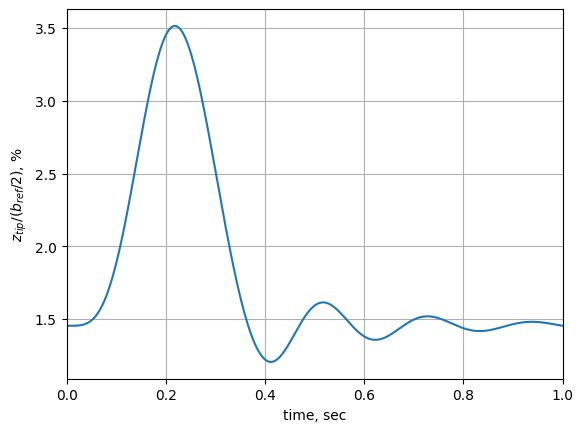

In [11]:
def get_resulting_vertical_tip_displacement(output_folder, model):
    file_results = os.path.join(output_folder,
                                 model.case_name,
                                 'WriteVariablesTime',
                                 'struct_pos_node{}.dat'.format(model.num_node_surf))
    print(model.num_node_surf)
    vertical_tip_displacement = np.loadtxt(file_results)[:,-1]


    return vertical_tip_displacement


tip_displacement_open_loop = get_resulting_vertical_tip_displacement(output_folder,
                                                                     pazy_model_open_loop)


time_array = np.arange(0, len(tip_displacement_open_loop) * pazy_model_open_loop.dt, pazy_model_open_loop.dt)
normalised_tip_displacement = tip_displacement_open_loop/ (0.5*pazy_model_open_loop.b_ref) #normalise by half wing span
normalised_tip_displacement *=100# cconvert to percentnvert to percent
plt.plot(time_array, normalised_tip_displacement)
plt.xlabel('time, sec')
plt.ylabel('$z_{tip}/(b_{ref}/2)$, %')
plt.xlim([0., simulation_time])
plt.grid()
plt.show()

### Wing Structural Comparission zTip

In [12]:
case_name = 'pazy_struct_response'

flow = ['BeamLoader',
        'NonLinearStatic',
        'NonLinearDynamic',
        # 'NonLinearDynamicPrescribedStep',
        'BeamPlot',
        'WriteVariablesTime',
        #'SaveData',
        ]

# simulation_time_struct  = simulation_time  # only one timestep has to be performed
simulation_time_struct  = 5  # only one timestep has to be performed
gust = False
num_modes = 20
unsteady_force_contribution = False
remove_gust_input_in_statespace = True

In [13]:
pazy_struct = wings.PazyControlSurface(M=number_chordwise_panels,
                                      N=number_spanwise_nodes,
                                      Mstar_fact=wake_length_factor,
                                      u_inf=u_inf,
                                      alpha=alpha_deg,
                                      rho=rho,
                                      n_surfaces=2,
                                      route=cases_folder + '/' + case_name,
                                      case_name=case_name,
                                      physical_time=simulation_time_struct,)

def generate_struct_fem_input_files(model):
    model.clean_test_files()
    model.update_derived_params()
    model.generate_fem_file()

generate_struct_fem_input_files(pazy_struct)

In [14]:
from get_settings_structTest import get_settings_structTest
print(pazy_struct.dt)
pazy_struct.set_default_config_dict()
pazy_struct.config = get_settings_structTest(pazy_struct,
                            flow,
                            num_cores=num_cores,
                            #wake_length_factor=wake_length_factor,
                            output_folder = output_folder,
                            #gust=gust,
                            #gust_settings=gust_settings,
                            num_modes = num_modes,
                            dt = pazy_model_open_loop.dt,
                            #rom_settings = rom_settings,
                            remove_gust_input_in_statespace=remove_gust_input_in_statespace,
                            unsteady_force_distribution=unsteady_force_contribution,
                            gravity_on = True)
                            #scaling_dict = scaling_dict)
                            #b_ref = b_ref)
pazy_struct.config.write()

0.001


In [15]:
#sharpy.sharpy_main.main(['', pazy_struct.route + pazy_struct.case_name + '.sharpy'])


In [66]:
# print(pazy_struct.num_node_surf)
# print( range(pazy_struct.num_node_surf))
# def get_resulting_vertical_tip_displacement(output_folder, model):
vertical_displacement = np.zeros(pazy_struct.num_node_surf)
y_axis = np.zeros(pazy_struct.num_node_surf)
for nNode in range(0,pazy_struct.num_node_surf-1):
    print(nNode)
    file_results = os.path.join(output_folder,
                                 pazy_struct.case_name,
                                 'WriteVariablesTime',
                                 # 'struct_pos_node{}.dat'.format(model.num_node_surf))
                                 'struct_pos_node{}.dat'.format(nNode+1))
    vertical_displacement[nNode] = np.loadtxt(file_results)[-1]
    y_axis[nNode] = np.loadtxt(file_results)[-2]
    print(vertical_displacement[nNode])
        # return vertical_displacement, y_axis

# [vertical_displacement,y_axis] = get_resulting_vertical_tip_displacement(output_folder,
                                                            # pazy_struct)

print(vertical_displacement)
print(y_axis)
# print(tip_displacement_test.shape) 
# print(y_axis.shape) 

# time_array = np.arange(0, len(vertical_displacement) * pazy_struct.dt, pazy_struct.dt)
wing_span =y_axis
normalised_tip_displacement = vertical_displacement/ (0.5*pazy_struct.b_ref) #normalise by half wing span
normalised_tip_displacement *=100# cconvert to percentnvert to percent
# plt.scatter(wing_span, vertical_displacement)
plt.scatter(wing_span, normalised_tip_displacement)

# for nNodes in range(pazy_struct.num_node_surf):
#     plt.scatter(wing_span[nNodes], vertical_displacement[nNodes])

plt.xlabel('y_len (m)')
plt.ylabel('$z_{tip}/(b_{ref}/2)$, %')
# plt.xlim([0., wing_span])
plt.grid()
plt.show()

0


FileNotFoundError: ./output/pazy_struct_response/WriteVariablesTime/struct_pos_node1.dat not found.

### Structural Modal Data

In [16]:
case_name = 'pazy_modal'

flow = ['BeamLoader',
        'AerogridLoader',
        'StaticCoupled',
        #'NonLinearStatic',
        'WriteVariablesTime',
        'Modal',
        'SaveData',
        ]
simulation_time_ROM = pazy_model_open_loop.dt # only one timestep has to be performed

gust = True

In [17]:
num_modes = 20
unsteady_force_contribution = False
remove_gust_input_in_statespace = False



In [18]:
pazy_modal_ROM = wings.PazyControlSurface(M=number_chordwise_panels,
                                      N=number_spanwise_nodes,
                                      Mstar_fact=wake_length_factor,
                                      u_inf=u_inf,
                                      alpha=alpha_deg,
                                      rho=rho,
                                      n_surfaces=2,
                                      route=cases_folder + '/' + case_name,
                                      case_name=case_name,
                                      physical_time=simulation_time_ROM,)

def generate_modal_fem_input_files(model):
    model.clean_test_files()
    model.update_derived_params()
    model.generate_aero_file()
    model.generate_fem_file()

generate_modal_fem_input_files(pazy_modal_ROM)

In [19]:
from get_settings_modal import get_settings_modal

pazy_modal_ROM.set_default_config_dict()
pazy_modal_ROM.config = get_settings_modal(pazy_modal_ROM,
                            flow,
                            num_cores=num_cores,
                            wake_length_factor=wake_length_factor,
                            output_folder = output_folder,
                            gust=gust,
                            gust_settings=gust_settings,
                            num_modes = num_modes,
                            #rom_settings = rom_settings,
                            remove_gust_input_in_statespace=remove_gust_input_in_statespace,
                            unsteady_force_distribution=unsteady_force_contribution,
                            gravity_on = True)
                            #scaling_dict = scaling_dict)
                            #b_ref = b_ref)
pazy_modal_ROM.config.write()

In [20]:
sharpy.sharpy_main.main(['', pazy_modal_ROM.route + pazy_modal_ROM.case_name + '.sharpy'])


********************************************************************************
         to build the TVTK classes (9.3). This may cause problems.
         Please rebuild TVTK.
********************************************************************************

--------------------------------------------------------------------------------
            ######  ##     ##    ###    ########  ########  ##    ##
           ##    ## ##     ##   ## ##   ##     ## ##     ##  ##  ##
           ##       ##     ##  ##   ##  ##     ## ##     ##   ####
            ######  ######### ##     ## ########  ########     ##
                 ## ##     ## ######### ##   ##   ##           ##
           ##    ## ##     ## ##     ## ##    ##  ##           ##
            ######  ##     ## ##     ## ##     ## ##           ##
--------------------------------------------------------------------------------
Aeroelastics Lab, Aeronautics Department.
    Copyright (c), Imperial College London.
    All rights reserved.

fatal: not a git repository (or any of the parent directories): .git


|      0       |   0.000000   |  29.991489   |   4.773294   |   4.773294   |  -0.000000   |   0.209499   |
|      1       |   0.000000   |  29.991492   |   4.773294   |   4.773294   |  -0.000000   |   0.209499   |
|      2       |   0.000000   |  189.417429  |  30.146720   |  30.146720   |  -0.000000   |   0.033171   |
|      3       |   0.000000   |  189.417568  |  30.146742   |  30.146742   |  -0.000000   |   0.033171   |
|      4       |   0.000000   |  263.274418  |  41.901425   |  41.901425   |  -0.000000   |   0.023866   |
|      5       |   0.000000   |  263.274596  |  41.901453   |  41.901453   |  -0.000000   |   0.023866   |
|      6       |   0.000000   |  537.690448  |  85.576093   |  85.576093   |  -0.000000   |   0.011686   |
|      7       |   0.000000   |  537.691623  |  85.576280   |  85.576280   |  -0.000000   |   0.011685   |
|      8       |   0.000000   |  696.032137  |  110.776955  |  110.776955  |  -0.000000   |   0.009027   |
|      9       |   0.000000   |  696.

### Aero SS Krylov Init

In [21]:
case_name = 'pazy_krylov_ROM'

flow = ['BeamLoader',
        'AerogridLoader',
        'StaticCoupled',
        'WriteVariablesTime',
        'DynamicCoupled',
        'Modal',
        'LinearAssembler',
        'SaveData',
        'SaveParametricCase',
        ]

simulation_time_ROM = pazy_model_open_loop.dt # only one timestep has to be performed
gust = True

In [22]:
use_rom = True

rom_settings = {
    'use': use_rom,
    'rom_method': 'Krylov',
    'rom_method_settings': {'Krylov': {
                                        'algorithm': 'mimo_rational_arnoldi',
                                        'r': 4,
                                        'frequency': np.array([0]),
                                        'single_side': 'observability',
                                        },
                           }
                }

In [23]:
num_modes = 20
unsteady_force_contribution = False
remove_gust_input_in_statespace = False



In [24]:
pazy_model_ROM = wings.PazyControlSurface(M=number_chordwise_panels,
                                      N=number_spanwise_nodes,
                                      Mstar_fact=wake_length_factor,
                                      u_inf=u_inf,
                                      alpha=alpha_deg,
                                      rho=rho,
                                      n_surfaces=2,
                                      route=cases_folder + '/' + case_name,
                                      case_name=case_name,
                                      physical_time=simulation_time_ROM,)

generate_aero_and_fem_input_files(pazy_model_ROM)

In [ ]:

#scaling_dict = {'length': .25*pazy_model_ROM.c_ref,
#'speed': u_inf,
#'density': rho}
#print(scaling_dict)

In [25]:
from get_settings_krylov import get_settings_krylov

pazy_model_ROM.set_default_config_dict()
pazy_model_ROM.config = get_settings_krylov(pazy_model_ROM,
                            flow,
                            num_cores=num_cores,
                            wake_length_factor=wake_length_factor,
                            output_folder = output_folder,
                            gust=gust,
                            gust_settings=gust_settings,
                            num_modes = num_modes,
                            rom_settings = rom_settings,
                            remove_gust_input_in_statespace=remove_gust_input_in_statespace,
                            unsteady_force_distribution=unsteady_force_contribution,
                            gravity_on = True)
                            #scaling_dict = scaling_dict)
                            #b_ref = b_ref)
pazy_model_ROM.config.write()

In [26]:
sharpy.sharpy_main.main(['', pazy_model_ROM.route + pazy_model_ROM.case_name + '.sharpy'])


--------------------------------------------------------------------------------
            ######  ##     ##    ###    ########  ########  ##    ##
           ##    ## ##     ##   ## ##   ##     ## ##     ##  ##  ##
           ##       ##     ##  ##   ##  ##     ## ##     ##   ####
            ######  ######### ##     ## ########  ########     ##
                 ## ##     ## ######### ##   ##   ##           ##
           ##    ## ##     ## ##     ## ##    ##  ##           ##
            ######  ##     ## ##     ## ##     ## ##           ##
--------------------------------------------------------------------------------
Aeroelastics Lab, Aeronautics Department.
    Copyright (c), Imperial College London.
    All rights reserved.
    License available at https://github.com/imperialcollegelondon/sharpy
Running SHARPy from /home/maxal/Research
SHARPy being run is in /home/maxal/.local/lib/python3.11/site-packages
SHARPy output folder set
	./output//pazy_krylov_ROM/
Generating an instanc

fatal: not a git repository (or any of the parent directories): .git


|  0  |  3  |  0.00000   |  0.0439  |  0.0000  | -1.9925  |  0.0000  |  0.0651  |  0.0000  |
|  1  |  3  |  -6.66131  |  0.0430  |  0.0000  | -1.9629  |  0.0000  |  0.0657  |  0.0000  |
|  0  |  4  |  0.00000   |  0.0544  |  0.0000  | -2.4479  |  0.0000  |  0.0822  |  0.0000  |
|  1  |  4  |  -6.46800  |  0.0533  |  0.0000  | -2.4103  |  0.0000  |  0.0830  |  0.0000  |
Generating an instance of WriteVariablesTime
Variable delimiter has no assigned value in the settings file.
    will default to the value:  
Variable FoR_variables has no assigned value in the settings file.
    will default to the value: ['']
Variable FoR_number has no assigned value in the settings file.
    will default to the value: [0]
Variable nonlifting_nodes_variables has no assigned value in the settings file.
    will default to the value: ['']
Variable nonlifting_nodes_im has no assigned value in the settings file.
    will default to the value: [0]
Variable nonlifting_nodes_in has no assigned value in the set

/home/maxal/.local/lib/python3.11/site-packages/sharpy/linear/src/lingebm.py:313: UserWarning: Euler parametrisation not implemented - Either rigid body modes are not being used or this method has already been called.
  warnings.warn('Euler parametrisation not implemented - Either rigid body modes are not being used or this '



Linearising gravity terms...
	M = 0.00 kg
	X_CG A -> -0.26 0.17 0.00
Node  1 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.069 -0.000
			-> G 0.000 0.069 -0.000
	Node mass:
		Matrix: 0.0403
Node  2 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.137 -0.001
			-> G 0.000 0.137 -0.001
	Node mass:
		Matrix: 0.0202
Node  3 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.206 -0.002
			-> G 0.000 0.206 -0.002
	Node mass:
		Matrix: 0.0403
Node  4 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.275 -0.003
			-> G 0.000 0.275 -0.003
	Node mass:
		Matrix: 0.0202
Node  5 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.344 -0.004
			-> G 0.000 0.344 -0.004
	Node mass:
		Matrix: 0.0403
Node  6 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.412 -0.005
			-> G 0.000 0.412 -0.005
	Node mass:
		Matrix: 0.0202
Node  7 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.481 -0.006
			-> G 0.000 0.481 -0.006
	Node mass:
		Matrix: 0.0403
Node  8 	-> B 0.003 -0.004 0.000
			-> A 0.004 0.553 -0.008
			-> G 0.004 0.553 -0.008
	Node mass:
		Matrix: 0.

### Matlab Sys Import and SS Construction

In [27]:
initial_cs_deflection = [0, 0]

In [28]:
folder_linear_results =os.path.join(output_folder, pazy_model_ROM.case_name,'linear_results')
if not os.path.exists(folder_linear_results):
    os.makedirs(folder_linear_results)

import scipy.io

parameter_matlab = {'num_aero_states': 80, # see log file
                    'num_modes': 20,  # see log file
                     'u_inf': float(pazy_model_ROM.u_inf),
                    'simulation_time': simulation_time,
                    'gust_length': float(gust_settings['gust_length']),
                    'gust_intensity': float(gust_settings['gust_intensity']),
                    'num_control_surfaces': num_control_surfaces,
                    'n_nodes': number_spanwise_nodes,
                    'control_input_start': 193 + 1, # see log file and + 1 for matlab indices
                    'gust_input_start': 192 + 1 , # see log file and + 1 for matlab indices
                    'aoa_deg': alpha_deg,
                    #'tip_displacement_open_loop': tip_displacement_open_loop[0],
                    #'cs_deflection': initial_cs_deflection[0],
                   }

scipy.io.savemat(os.path.join(folder_linear_results, 'simulation_parameters.mat'), parameter_matlab)

In [29]:



# Get the path to the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)
mat_dir = parent_dir + '/MatlabFlex'
print(mat_dir)
config_dict = mat_dir + '/' + 'configs'
print(config_dict)
print(route_notebook_dir)
#run_sim_dict = mat_dir + '/AeroFlex/' + 'sim'
#run_sim_dict = mat_dir + '/' + 'AeroFlex'
#run_sim_dict = mat_dir + '/' + 'AeroFlex' + '/' + 'sim'
run_sim_dict = mat_dir + '/' + 'tests'
print(run_sim_dict)
print(case_name)

/home/maxal/Research/MatlabFlex
/home/maxal/Research/MatlabFlex/configs
/home/maxal/Research/TestBenchPazy
/home/maxal/Research/MatlabFlex/tests
pazy_krylov_ROM


In [ ]:

# THIS IS SIM SETUP SCRIPT

eng = matlab.engine.start_matlab()
# print(eng.path)
# eng.addpath(current_directory)
eng.addpath(mat_dir)
eng.addpath(config_dict)
# eng.addpath("/mnt/c/Users/maxal/Documents/JupyterNotebooks/ControlsProj/example_notebooks/UDP_control")
# eng.addpath("/mnt/c/Users/maxal/Documents/JupyterNotebooks/ControlsProj/example_notebooks/UDP_control/matlab_functions")

## Openloop is default
eng.sim_init(route_notebook_dir,'overwrite', True)


## Clamped nMHE & nMPC wing case
# eng.sim_init(route_notebook_dir,'overwrite', True, 'sim_case','nmhe_nmpc')

# NOTE: NEED TO SETUP FULLY COUPLED CASE. Only wing only runs rn

In [ ]:
# THIS IS SIM RUN SCRIPT


eng.addpath(run_sim_dict)
# keep overwrite on
eng.sim_run(case_name,'wingOnly','overwrite', True)
# eng.sim_run(case_name,'wingOnly', 'setup_dir','/home/maxal/Research/TestBench/sim_setup/pazy_krylov_ROM/wing_only/20251111')

[info] MATLAB run dir: /home/maxal/Research/TestBenchPazy/sim_run/pazy_krylov_ROM/wing_only/20260506 (case='pazy_krylov_ROM')


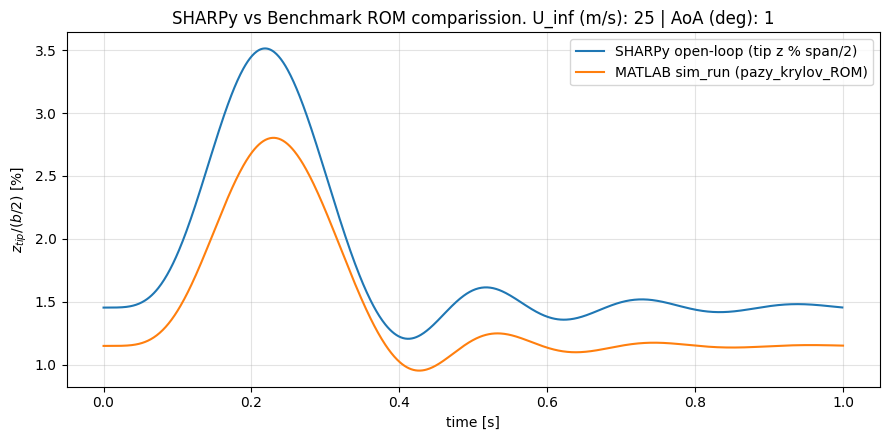

[info] SHARPy case     : pazy_open_loop_gust_response
[info] MATLAB case     : pazy_krylov_ROM
[info] MATLAB run path : /home/maxal/Research/TestBenchPazy/sim_run/pazy_krylov_ROM/wing_only/20260506


In [33]:
import glob

# nb_root = "/home/maxal/Research/TestBenchPazy"
nb_root = route_notebook_dir
sharpy_case_name   = "pazy_open_loop_gust_response"   # SHARPy case on disk
matlab_case_hint   = None     # e.g. "pazy_krylov_ROM" or None to auto
matlab_run_dir     = None     # full path to a specific dated run to bypass auto-discovery
# If already have pazy_model_open_loop in scope,  reuse it; else set these 3:
# pazy_model_open_loop.case_name, .dt, .b_ref must exist.
# ----------------------------------

def peek_dir(root, depth=2):
    if not os.path.isdir(root):
        print(f"[peek] {root} (missing)"); return
    print(f"[peek] {root}")
    base = root.rstrip(os.sep).count(os.sep)
    for dp, dns, fns in os.walk(root):
        d = dp.count(os.sep) - base
        if d > depth:
            dns[:] = []
            continue
        ind = "  " * d
        print(f"{ind}- {os.path.basename(dp)}/")
        for f in fns:
            print(f"{ind}  · {f}")

def ascend_to_run_root(path):
    """Walk up until we find meta_run.yaml; return that folder (or None)."""
    p = os.path.abspath(path)
    while True:
        if os.path.isfile(os.path.join(p, "meta_run.yaml")):
            return p
        parent = os.path.dirname(p)
        if parent == p:
            return None
        p = parent

def find_matlab_run_dir(nb_root, case_hint=None, manual=None):
    """Find the most recent MATLAB run root under sim_run/*/*/<date> regardless of body_case spelling."""
    sim_run_base = os.path.join(nb_root, "sim_run")
    if manual:
        if not os.path.isdir(manual):
            raise FileNotFoundError(f"Manual matlab_run_dir does not exist: {manual}")
        return manual, os.path.basename(os.path.dirname(os.path.dirname(manual)))  # (run_dir, case)

    # Search patterns across ALL body-case spellings and subtrees
    patterns = [
        os.path.join(sim_run_base, "*", "*", "**", "sim_out.h5"),
        os.path.join(sim_run_base, "*", "*", "**", "tip_z_norm_pct.csv"),
        os.path.join(sim_run_base, "*", "*", "**", "tip_z.csv"),
        os.path.join(sim_run_base, "*", "*", "**", "xcell", "timeseries.xlsx"),
        os.path.join(sim_run_base, "*", "*", "**", "for_sharpy", "sim_run_out.h5"),
    ]
    hits = []
    for pat in patterns:
        hits.extend(glob.glob(pat, recursive=True))
    # Map each hit back to the dated run root (meta_run.yaml container)
    run_dirs = []
    for hit in hits:
        root = ascend_to_run_root(os.path.dirname(hit))
        if root:
            run_dirs.append(root)
    run_dirs = sorted(set(run_dirs), key=lambda p: os.path.getmtime(p))
    if not run_dirs:
        print("[diag] Could not find MATLAB sim_run outputs. Quick tree:")
        peek_dir(sim_run_base, depth=4)
        raise FileNotFoundError("Could not find MATLAB sim_run outputs (H5/CSV/xcell/for_sharpy).")

    # If a hint is given, prefer that case; otherwise take the newest overall
    if case_hint:
        cand = [r for r in run_dirs if os.path.normpath(r).split(os.sep)[-3] == case_hint]
        if cand:
            chosen = cand[-1]
        else:
            chosen = run_dirs[-1]
    else:
        chosen = run_dirs[-1]

    parts = os.path.normpath(chosen).split(os.sep)
    # sim_run/<case>/<body_case>/<date>
    resolved_case = parts[-3] if len(parts) >= 3 else "<unknown>"
    return chosen, resolved_case

def load_matlab_tip(run_dir, b_ref_for_norm=None):
    """
    Load tip (normalized %) from, in order:
      1) <run>/sim_out.h5 datasets: /tip_z_norm_pct or /tip_z (+normalize)
      2) CSVs in run root: tip_z_norm_pct.csv, tip_z.csv (+normalize), optional time.csv
      3) CSVs in run/post/: tip_z_norm_pct.csv, tip_z.csv (+normalize), optional time.csv
      4) Excel in run/xcell/timeseries.xlsx (columns: time, tip_z, tip_z_norm_pct)
      5) H5 in run/for_sharpy/sim_run_out.h5: datasets /time, /tip_z
    Returns (t, tip_pct) where t may be None if not stored.
    """
    # 1) H5 at root
    h5 = os.path.join(run_dir, "sim_out.h5")
    if os.path.exists(h5):
        try:
            import h5py
            with h5py.File(h5, "r") as f:
                t = np.array(f["/time"]).ravel() if "/time" in f else None
                if "/tip_z_norm_pct" in f:
                    return t, np.array(f["/tip_z_norm_pct"]).ravel()
                if "/tip_z" in f:
                    tip = np.array(f["/tip_z"]).ravel()
                    # tip_pct = 100.0 * tip / (0.5 * b_ref_for_norm) if b_ref_for_norm is not None else tip
                    tip_pct = 100.0 * tip / (b_ref_for_norm) if b_ref_for_norm is not None else tip
                    return t, tip_pct
        except Exception as e:
            print(f"[warn] root H5 read failed: {e}")

    # helper to read CSVs in a folder
    def _load_csv(folder):
        fn = os.path.join(folder, "tip_z_norm_pct.csv")
        if os.path.exists(fn):
            tip_pct = np.loadtxt(fn, delimiter=",").ravel()
            tfn = os.path.join(folder, "time.csv")
            t = np.loadtxt(tfn, delimiter=",").ravel() if os.path.exists(tfn) else None
            return t, tip_pct
        fn = os.path.join(folder, "tip_z.csv")
        if os.path.exists(fn):
            tip = np.loadtxt(fn, delimiter=",").ravel()
            # tip_pct = 100.0 * tip / (0.5 * b_ref_for_norm) if b_ref_for_norm is not None else tip
            tip_pct = 100.0 * tip / ( b_ref_for_norm) if b_ref_for_norm is not None else tip
            tfn = os.path.join(folder, "time.csv")
            t = np.loadtxt(tfn, delimiter=",").ravel() if os.path.exists(tfn) else None
            return t, tip_pct
        return None, None

    # 2) root CSVs
    t, tip_pct = _load_csv(run_dir)
    if tip_pct is not None:
        return t, tip_pct

    # 3) post/ CSVs
    t, tip_pct = _load_csv(os.path.join(run_dir, "post"))
    if tip_pct is not None:
        return t, tip_pct

    # 4) xcell Excel
    xls = os.path.join(run_dir, "xcell", "timeseries.xlsx")
    if os.path.exists(xls):
        try:
            import pandas as pd
            df = pd.read_excel(xls, sheet_name="timeseries")
            if "tip_z_norm_pct" in df.columns:
                t = df["time"].to_numpy().ravel() if "time" in df.columns else None
                return t, df["tip_z_norm_pct"].to_numpy().ravel()
            if "tip_z" in df.columns:
                tip = df["tip_z"].to_numpy().ravel()
                # tip_pct = 100.0 * tip / (0.5 * b_ref_for_norm) if b_ref_for_norm is not None else tip
                tip_pct = 100.0 * tip / ( b_ref_for_norm) if b_ref_for_norm is not None else tip
                t = df["time"].to_numpy().ravel() if "time" in df.columns else None
                return t, tip_pct
        except Exception as e:
            print(f"[warn] Excel read failed: {e}")

    # 5) for_sharpy H5
    h5fs = os.path.join(run_dir, "for_sharpy", "sim_run_out.h5")
    if os.path.exists(h5fs):
        try:
            import h5py
            with h5py.File(h5fs, "r") as f:
                t = np.array(f["/time"]).ravel() if "/time" in f else None
                if "/tip_z" in f:
                    tip = np.array(f["/tip_z"]).ravel()
                    # tip_pct = 100.0 * tip / (0.5 * b_ref_for_norm) if b_ref_for_norm is not None else tip
                    tip_pct = 100.0 * tip / ( b_ref_for_norm) if b_ref_for_norm is not None else tip
                    return t, tip_pct
        except Exception as e:
            print(f"[warn] for_sharpy H5 read failed: {e}")

    return None, None

# --------- SHARPy reference (same helper you used) ----------
def get_resulting_vertical_tip_displacement(output_folder, model):
    f = os.path.join(output_folder, model.case_name, "WriteVariablesTime",
                     f"struct_pos_node{model.num_node_surf}.dat")
    return np.loadtxt(f)[:,-1]

# --------- Load SHARPy open-loop ----------
output_folder = os.path.join(nb_root, "output")
tip_sh = get_resulting_vertical_tip_displacement(output_folder, pazy_model_open_loop)
t_sh   = np.arange(0, len(tip_sh)) * pazy_model_open_loop.dt
tip_sh_pct = 100.0 * tip_sh / (0.5 * pazy_model_open_loop.b_ref)

# --------- Find MATLAB run & load tip ----------
run_dir, resolved_case = find_matlab_run_dir(nb_root, case_hint=matlab_case_hint, manual=matlab_run_dir)
print(f"[info] MATLAB run dir: {run_dir} (case='{resolved_case}')")

t_sim, tip_sim_pct = load_matlab_tip(run_dir, b_ref_for_norm=pazy_model_open_loop.b_ref)
if tip_sim_pct is None:
    raise FileNotFoundError(f"No usable MATLAB tip outputs inside: {run_dir}")

if t_sim is None:
    # use SHARPy time for plotting if MATLAB time missing
    t_sim = t_sh[:len(tip_sim_pct)]

# --------- Plot ----------
plt.figure(figsize=(9,4.5))
plt.title(f"SHARPy vs Benchmark ROM comparission. U_inf (m/s): {u_inf} | AoA (deg): {alpha_deg}")

plt.plot(t_sh,  tip_sh_pct,  label="SHARPy open-loop (tip z % span/2)")
# plt.plot(t_sim, -1+-1*tip_sim_pct, label=f"MATLAB sim_run ({resolved_case})")
# plt.plot(t_sim, -1*tip_sim_pct, label=f"MATLAB sim_run ({resolved_case})")
plt.plot(t_sim, (1)*tip_sim_pct, label=f"MATLAB sim_run ({resolved_case})")
plt.xlabel("time [s]"); plt.ylabel("$z_{tip}/(b/2)$ [%]")
plt.grid(True, alpha=0.35); plt.legend(); plt.tight_layout(); plt.show()
print(f"[info] SHARPy case     : {sharpy_case_name}")
print(f"[info] MATLAB case     : {resolved_case}")
print(f"[info] MATLAB run path : {run_dir}")



### Coupled Wing Cases Runs


In [34]:
# Clean Up Simulink Files
import shutil
folder_path = os.path.join(route_notebook_dir, 'slprj')
if os.path.exists(folder_path):
    shutil.rmtree(folder_path)

file_path = os.path.join(route_notebook_dir,  'PID_linear_model.slxc')
if os.path.exists(file_path):
    os.remove(file_path)


In [35]:
# Load linear results
tip_deflection_linear = np.loadtxt(folder_linear_results + '/tip_deflection.txt', delimiter = ',')
time_array_linear = np.loadtxt(folder_linear_results + '/time_array_linear.txt', delimiter = ',')
normalised_tip_deflection_linear = tip_deflection_linear / (0.5 *pazy_model_ROM.b_ref) * 100
control_surface_deflection_deg = np.loadtxt(folder_linear_results + '/deflection.txt', delimiter = ',')
control_surface_deflection_rate_deg = np.loadtxt(folder_linear_results + '/deflection_rate.txt', delimiter = ',')

# Plot Data
fig, axs = plt.subplots(3, 1)
list_linestyles = ['-', '-', '--', ':']
list_labels = ['linear P=5', 'linear P=10', 'linear open-loop', 'nonlinear open-loop']
for i in range(3):
    axs[0].plot(time_array_linear, normalised_tip_deflection_linear[:,i], list_linestyles[i], label=list_labels[i])

axs[0].plot(time_array, normalised_tip_displacement, list_linestyles[-1], label=list_labels[-1])
axs[0].legend(loc ='upper right')
axs[0].set(ylabel='$z_{tip}/(b_{ref}/2)$, %')

for i in range(3):
    axs[1].plot(time_array_linear, control_surface_deflection_deg[:,i], list_linestyles[i])

axs[1].set(ylabel='$\delta$, deg')
for i in range(3):
    axs[2].plot(time_array_linear, control_surface_deflection_rate_deg[:,i], list_linestyles[i])

axs[2].set(ylabel='$\dot{\delta}$, deg/sec')
for ax in axs.flat:
    ax.set(xlabel='time, sec')


FileNotFoundError: ./output/pazy_krylov_ROM/linear_results/tip_deflection.txt not found.

In [ ]:
case_name = 'pazy_udp_closed_loop_gust_response'
gust = True
flow = ['BeamLoader',
        'AerogridLoader',
        'StaticCoupled',
        'DynamicCoupled',
        ]

In [ ]:
initial_cs_deflection = [0, 0]
cs_type = 2

In [ ]:
pazy_model_closed = wings.PazyControlSurface(M=number_chordwise_panels,
                                      N=number_spanwise_nodes,
                                      Mstar_fact=wake_length_factor,
                                      u_inf=u_inf,
                                      alpha=alpha_deg,
                                      cs_deflection=initial_cs_deflection,
                                      rho=rho,
                                      n_surfaces=2,
                                      route=cases_folder + '/' + case_name,
                                      case_name=case_name,
                                      physical_time=simulation_time,
                                      cs_type=cs_type)
generate_aero_and_fem_input_files(pazy_model_closed)

In [ ]:
#  Network settings for nonlinear in closed-loop simulations
server_ip_addr = '127.0.0.1' # SHARPy
client_ip_addr = '127.0.0.1' # controller
port_in_network = 64017
port_out_network_server = 59017
port_out_network_client = 44249
num_sensors = 1
network_settings = {'variables_filename': '/mnt/c/Users/maxal/Documents/JupyterNotebooks/ControlsProj/example_notebooks/UDP_control' + '/pazy_network_info.yml',
                                        'send_output_to_all_clients': False,
                                        'byte_ordering': 'little',
                                        'log_name': output_folder +'/'+ case_name + '/sharpy_network.log',
                                        'file_log_level': 'debug',
                                        'console_log_level': 'error',
                                        'input_network_settings': {'address': server_ip_addr,
                                                                        'port': port_in_network,
                                                                        },
                                        'output_network_settings': {'send_on_demand': False,
                                                                        'port': port_out_network_server,
                                                                        'address':server_ip_addr,
                                                                        'destination_address': [client_ip_addr],
                                                                        'destination_ports': [port_out_network_client],
                                                                }
                                                }


In [ ]:
pazy_model_closed.set_default_config_dict()
pazy_model_closed.config = get_settings_udp(pazy_model_closed,
                            flow,
                            network_settings=network_settings,
                            num_cores=num_cores,
                            wake_length_factor=wake_length_factor,
                            output_folder = output_folder,
                            gust=gust,
                            gust_settings=gust_settings,
                            write_screen = True)
pazy_model_closed.config.write()

In [ ]:
dict_parameters = {"server_ip_addr": server_ip_addr,
                   "client_ip_addr": client_ip_addr,
                   "port_in_network": port_in_network,
                   "port_out_network_server": port_out_network_server,
                   "port_out_network_client": port_out_network_client,
                   "output_folder": os.path.abspath(output_folder),
                   "dt": pazy_model_closed.dt,
                   "simulation_time": simulation_time,
                   "num_sensors": num_sensors,
                   "initial_cs_deflection": initial_cs_deflection[0],
                   "reference_deflection": tip_displacement_open_loop[0],
                  }
with open('./parameter_UDP_control_{}.json'.format(pazy_model_closed.case_name), 'w') as fp:
    json.dump(dict_parameters, fp)

In [ ]:
sharpy.sharpy_main.main(['', pazy_model_closed.route + pazy_model_closed.case_name + '.sharpy']);

In [ ]:
control_surface_input = np.loadtxt(os.path.join(output_folder, pazy_model_closed.case_name, "pazy_udp_closed_loop_gust_response_control_input"))
delta_dot = np.diff(np.rad2deg(control_surface_input))/pazy_model_closed.dt
tip_displacement_nonlinear_P10 = np.loadtxt(os.path.join(output_folder, pazy_model_closed.case_name, "pazy_udp_closed_loop_gust_response_sensor_measurement"))
time_array_nonlinear_closed_loop = np.arange(0, len(tip_displacement_nonlinear_P10) * pazy_model_closed.dt, pazy_model_closed.dt)
tip_displacement_nonlinear_P10 /= pazy_model_closed.b_ref/2
tip_displacement_nonlinear_P10 *= 100

In [ ]:
# Plot Data
fig, axs = plt.subplots(3, 1)
list_linestyles = ['-', '--', ':']
list_labels = ['linear P=10', 'nonlinear P=10', 'nonlinear open-loop']
axs[0].plot(time_array_linear, normalised_tip_deflection_linear[:,1], list_linestyles[0], label=list_labels[0])
axs[0].plot(time_array_nonlinear_closed_loop,
            tip_displacement_nonlinear_P10,
            list_linestyles[1],
            label=list_labels[1])
axs[0].plot(time_array, normalised_tip_displacement, list_linestyles[-1], label=list_labels[-1])

axs[0].legend()
axs[0].set(ylabel='$z_{tip}/(b_{ref}/2)$, %')


axs[1].plot(time_array_linear, control_surface_deflection_deg[:,1], list_linestyles[0])
axs[1].plot(time_array_nonlinear_closed_loop, np.rad2deg(control_surface_input), list_linestyles[1])

axs[1].set(ylabel='$\delta$, deg')

axs[2].plot(time_array_linear, control_surface_deflection_rate_deg[:,0], list_linestyles[0])
axs[2].plot(time_array_nonlinear_closed_loop[1:],
            delta_dot,
            list_linestyles[1])

axs[2].set(ylabel='$\dot{\delta}$, deg/sec')
for ax in axs.flat:
    ax.set(xlabel='time, sec')